In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import warnings
warnings.filterwarnings('ignore')

# Load processed data and model
print("Loading data and model...")
X_train = pd.read_csv('X_train.csv')
X_test = pd.read_csv('X_test.csv')
y_test = pd.read_csv('y_test.csv').squeeze()

# Reload model
from xgboost import XGBClassifier
model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=27,
    random_state=42,
    eval_metric='aucpr',
    n_jobs=-1
)

y_train = pd.read_csv('y_train.csv').squeeze()
model.fit(X_train, y_train, verbose=False)
print("Model ready.")

# Use a sample for SHAP (full dataset takes too long)
# Stratified sample: 2000 legitimate + 2000 fraud
sample_legit = X_test[y_test == 0].sample(2000, random_state=42)
sample_fraud = X_test[y_test == 1].sample(2000, random_state=42)
X_sample = pd.concat([sample_legit, sample_fraud])
y_sample = pd.concat([y_test[y_test == 0].sample(2000, random_state=42),
                      y_test[y_test == 1].sample(2000, random_state=42)])

print(f"\nSHAP sample: {X_sample.shape}")
print("Computing SHAP values (this may take 2-3 minutes)...")

# SHAP explainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)

print("SHAP values computed.")

Loading data and model...
Model ready.

SHAP sample: (4000, 363)
Computing SHAP values (this may take 2-3 minutes)...
SHAP values computed.


Generating SHAP summary plot...


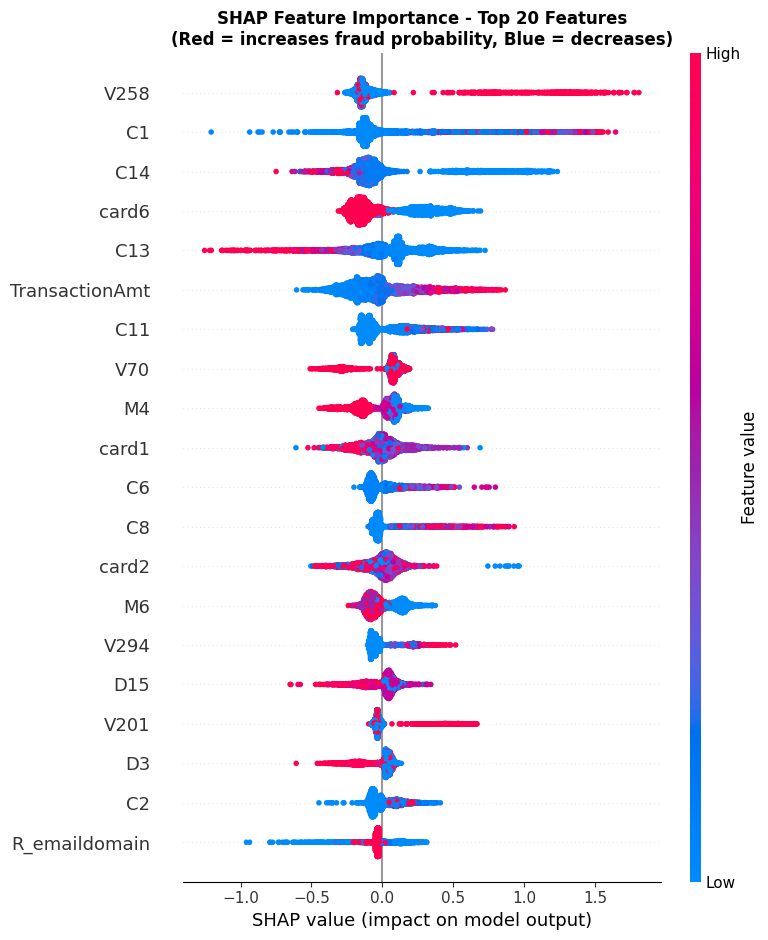

Saved: 08_shap_summary.png

=== TOP 10 MOST IMPORTANT FEATURES ===
  V258                           0.2681
  C1                             0.2568
  C14                            0.2297
  card6                          0.2078
  C13                            0.1948
  TransactionAmt                 0.1830
  C11                            0.1566
  V70                            0.1337
  M4                             0.1186
  card1                          0.1035


In [2]:
# SHAP Summary Plot - Global Feature Importance
print("Generating SHAP summary plot...")

plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values, 
    X_sample, 
    max_display=20,
    show=False
)
plt.title('SHAP Feature Importance - Top 20 Features\n(Red = increases fraud probability, Blue = decreases)', 
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('08_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 08_shap_summary.png")

# Top 10 features by mean absolute SHAP value
feature_importance = pd.DataFrame({
    'feature': X_sample.columns,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False).head(10)

print("\n=== TOP 10 MOST IMPORTANT FEATURES ===")
for i, row in feature_importance.iterrows():
    print(f"  {row['feature']:<30} {row['mean_abs_shap']:.4f}")

Explaining transaction index: 2248
Actual label: FRAUD
Model fraud probability: 0.9995


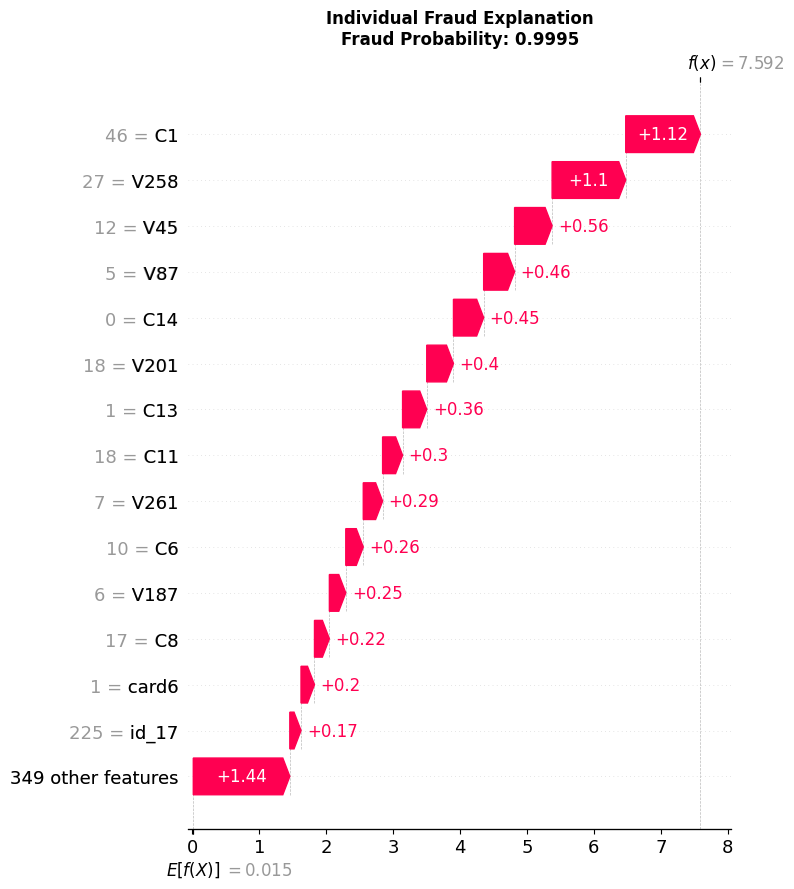

Saved: 09_shap_waterfall.png


In [3]:
# Individual prediction explanation - Waterfall plot
# Explain a single fraud case

# Find a high-confidence fraud prediction
y_sample_reset = y_sample.reset_index(drop=True)
fraud_indices = y_sample_reset[y_sample_reset == 1].index.tolist()

# Pick the fraud case with highest model confidence
proba_sample = model.predict_proba(X_sample)[:, 1]
high_conf_fraud_idx = fraud_indices[np.argmax(proba_sample[fraud_indices])]

print(f"Explaining transaction index: {high_conf_fraud_idx}")
print(f"Actual label: {'FRAUD' if y_sample_reset[high_conf_fraud_idx] == 1 else 'LEGITIMATE'}")
print(f"Model fraud probability: {proba_sample[high_conf_fraud_idx]:.4f}")

# Waterfall plot
shap_explanation = shap.Explanation(
    values=shap_values[high_conf_fraud_idx],
    base_values=explainer.expected_value,
    data=X_sample.iloc[high_conf_fraud_idx],
    feature_names=X_sample.columns.tolist()
)

plt.figure(figsize=(10, 8))
shap.plots.waterfall(shap_explanation, max_display=15, show=False)
plt.title(f'Individual Fraud Explanation\nFraud Probability: {proba_sample[high_conf_fraud_idx]:.4f}',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('09_shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 09_shap_waterfall.png")

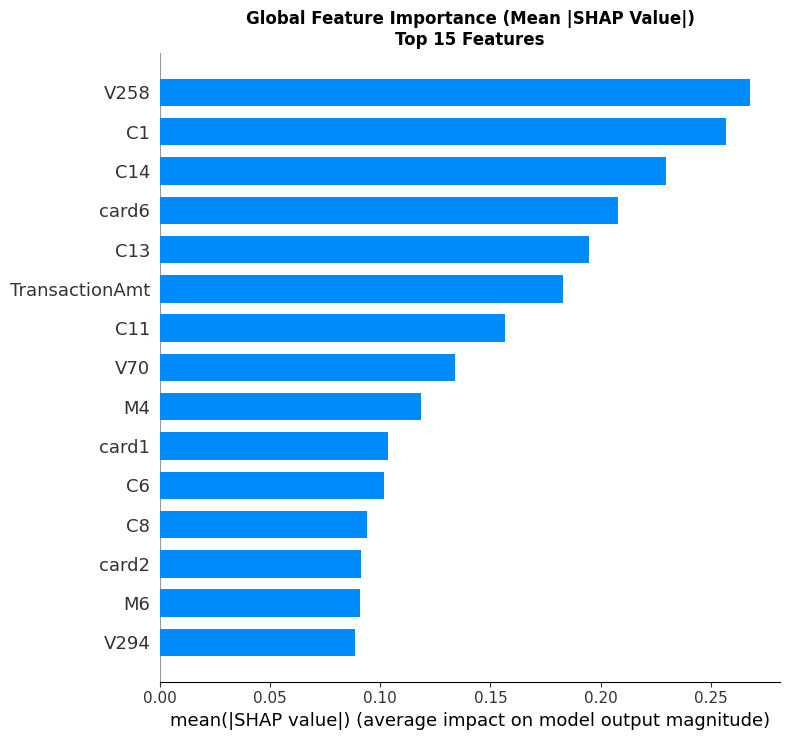

Saved: 10_shap_bar.png

SHAP Explainability complete. Ready for Bias Analysis.


In [4]:
# Global feature importance - Bar plot (cleaner version for report)
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values,
    X_sample,
    plot_type='bar',
    max_display=15,
    show=False
)
plt.title('Global Feature Importance (Mean |SHAP Value|)\nTop 15 Features', 
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('10_shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 10_shap_bar.png")
print("\nSHAP Explainability complete. Ready for Bias Analysis.")